In [20]:
# =========================
# CORE DATA HANDLING
# =========================
import pandas as pd
import numpy as np

# =========================
# TEXT CLEANING
# =========================
import re
import string

# =========================
# VISUALIZATION (EDA + EVALUATION)
# =========================
import matplotlib.pyplot as plt

# =========================
# SCIKIT-LEARN (ML + NLP)
# =========================
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# =========================
# XGBOOST
# =========================
from xgboost import XGBClassifier

# =========================
# MODEL SAVE / LOAD (FOR API)
# =========================
import joblib

# =========================
# BERT / DEEP LEARNING
# =========================
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from sentence_transformers import SentenceTransformer

In [3]:
real = pd.read_csv("D:\\Fake_News_Detection_Project\\data\\True.csv")
fake = pd.read_csv("D:\\Fake_News_Detection_Project\\data\\Fake.csv")

print("Real News Shape:", real.shape)
print("Fake News Shape:", fake.shape)

real["label"] = 1
fake["label"] = 0

df = pd.concat([real, fake], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

print(df["label"].value_counts())


Real News Shape: (21417, 4)
Fake News Shape: (23481, 4)
label
0    23481
1    21417
Name: count, dtype: int64


In [4]:
df = df[["title", "text", "label"]]
df["content"] = df["title"].astype(str) + " " + df["text"].astype(str)
df = df.drop(["title", "text"], axis=1)

In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    return text

df["content"] = df["content"].apply(clean_text)

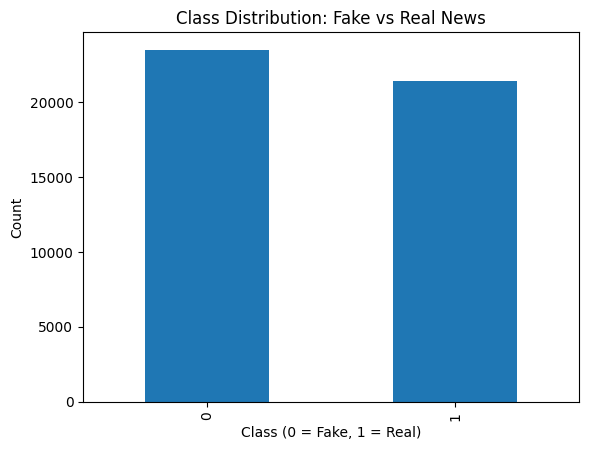

In [6]:
plt.figure()
df["label"].value_counts().plot(kind="bar")
plt.title("Class Distribution: Fake vs Real News")
plt.xlabel("Class (0 = Fake, 1 = Real)")
plt.ylabel("Count")
plt.savefig("Fig1_Class_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

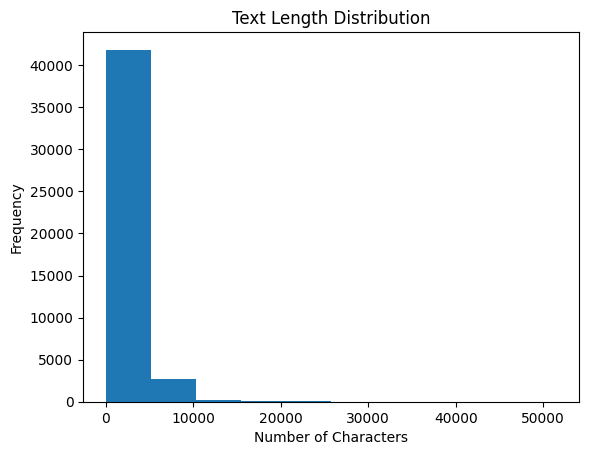

In [6]:
df["text_length"] = df["content"].str.len()

plt.figure()
plt.hist(df["text_length"])
plt.title("Text Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.savefig("Fig2_Text_Length_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()


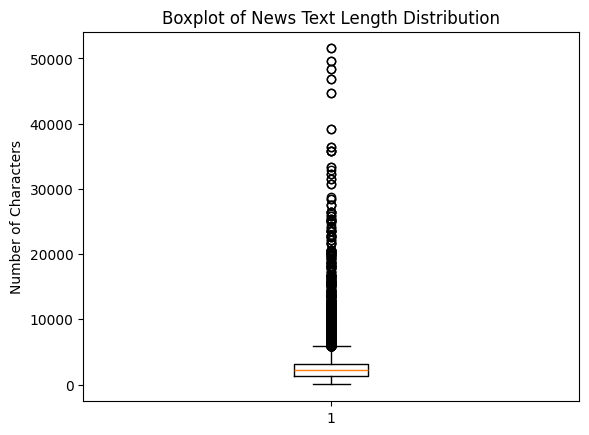

In [7]:
plt.figure()
plt.boxplot(df["text_length"])
plt.title("Boxplot of News Text Length Distribution")
plt.ylabel("Number of Characters")
plt.savefig("Fig7_Boxplot_Text_Length.png", dpi=300, bbox_inches="tight")
plt.show()


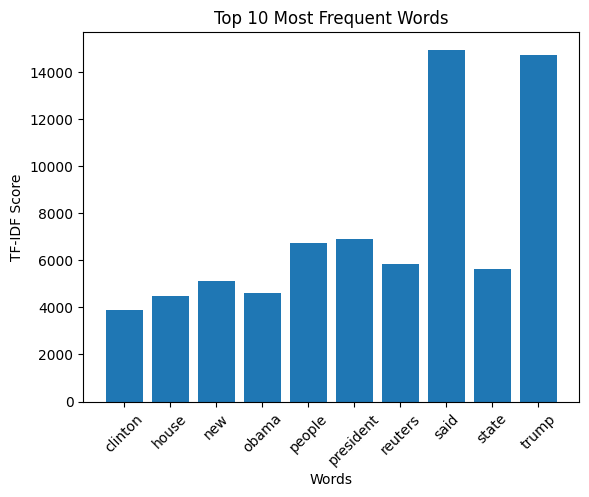

In [8]:
vectorizer_eda = TfidfVectorizer(max_features=10, stop_words="english")
X_eda = vectorizer_eda.fit_transform(df["content"])

words = vectorizer_eda.get_feature_names_out()
scores = X_eda.sum(axis=0).A1

plt.figure()
plt.bar(words, scores)
plt.title("Top 10 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("TF-IDF Score")
plt.xticks(rotation=45)
plt.savefig("Fig3_Word_Frequency.png", dpi=300, bbox_inches="tight")
plt.show()


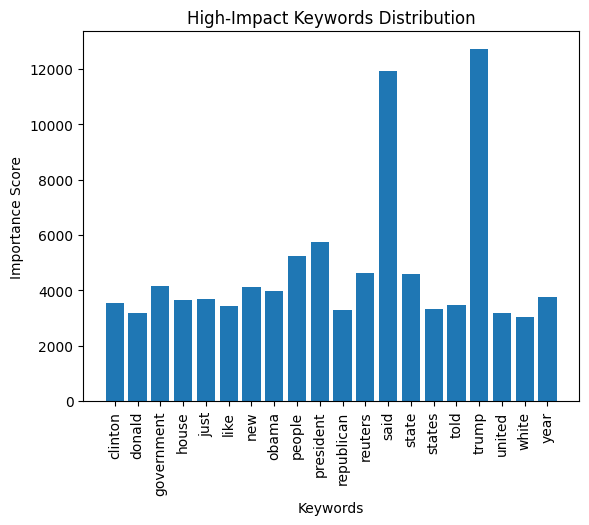

In [9]:
vectorizer_wc = TfidfVectorizer(max_features=20, stop_words="english")
X_wc = vectorizer_wc.fit_transform(df["content"])

wc_words = vectorizer_wc.get_feature_names_out()
wc_scores = X_wc.sum(axis=0).A1

plt.figure()
plt.bar(wc_words, wc_scores)
plt.title("High-Impact Keywords Distribution")
plt.xlabel("Keywords")
plt.ylabel("Importance Score")
plt.xticks(rotation=90)
plt.savefig("Fig4_High_Impact_Keywords.png", dpi=300, bbox_inches="tight")
plt.show()


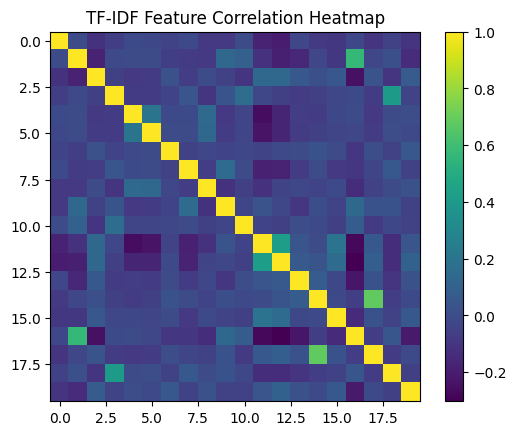

In [10]:
vectorizer_corr = TfidfVectorizer(max_features=20, stop_words="english")
X_corr = vectorizer_corr.fit_transform(df["content"]).toarray()

tfidf_df = pd.DataFrame(X_corr, columns=vectorizer_corr.get_feature_names_out())
corr_matrix = tfidf_df.corr()

plt.figure()
plt.imshow(corr_matrix)
plt.title("TF-IDF Feature Correlation Heatmap")
plt.colorbar()
plt.savefig("Fig5_TFIDF_Correlation_Heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


In [7]:
X = df["content"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [8]:
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


In [9]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [10]:

lr_pred = lr_model.predict(X_test_tfidf)
lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.9878619153674832


In [11]:
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=20, 
    random_state=42, 
    n_jobs=-1
)
rf_model.fit(X_train_tfidf, y_train)

RandomForestClassifier(max_depth=20, n_jobs=-1, random_state=42)

In [12]:
rf_pred = rf_model.predict(X_test_tfidf)
rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.9947661469933184


In [13]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1   # use all CPU cores
)


xgb_model.fit(X_train_tfidf, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [14]:
xgb_pred = xgb_model.predict(X_test_tfidf)
xgb_acc = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_acc)

XGBoost Accuracy: 0.9977728285077951


In [21]:
bert_model = SentenceTransformer("all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

C:\Python313\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\hp\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [22]:
X_train_bert = bert_model.encode(X_train.tolist(), show_progress_bar=True)
X_test_bert = bert_model.encode(X_test.tolist(), show_progress_bar=True)

Batches:   0%|          | 0/1123 [00:00<?, ?it/s]

Batches:   0%|          | 0/281 [00:00<?, ?it/s]

In [23]:
bert_clf = LogisticRegression(max_iter=1000)
bert_clf.fit(X_train_bert, y_train)

bert_pred = bert_clf.predict(X_test_bert)
bert_acc = accuracy_score(y_test, bert_pred)

print("BERT (MiniLM) Accuracy:", bert_acc)


BERT (MiniLM) Accuracy: 0.9402004454342985


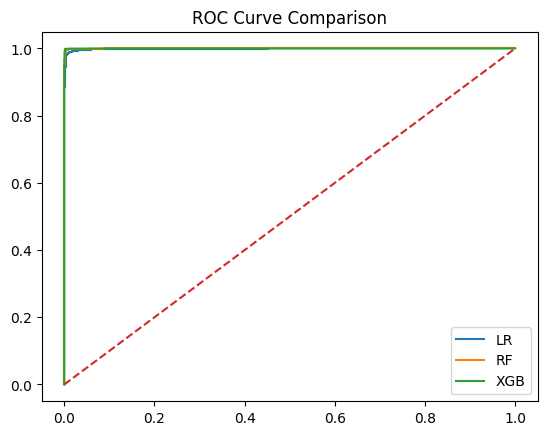

In [24]:
lr_probs = lr_model.predict_proba(X_test_tfidf)[:, 1]
rf_probs = rf_model.predict_proba(X_test_tfidf)[:, 1]
xgb_probs = xgb_model.predict_proba(X_test_tfidf)[:, 1]

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)

plt.figure()
plt.plot(lr_fpr, lr_tpr, label="LR")
plt.plot(rf_fpr, rf_tpr, label="RF")
plt.plot(xgb_fpr, xgb_tpr, label="XGB")
plt.plot([0,1],[0,1],"--")
plt.legend()
plt.title("ROC Curve Comparison")
plt.savefig("Fig6_ROC.png", dpi=300)
plt.show()


In [25]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost", "Fast BERT (MiniLM)"],
    "Accuracy": [lr_acc, rf_acc, xgb_acc, bert_acc]
})

print(results)


                 Model  Accuracy
0  Logistic Regression  0.987862
1        Random Forest  0.994766
2              XGBoost  0.997773
3   Fast BERT (MiniLM)  0.940200


In [26]:
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")
joblib.dump(xgb_model, "fake_news_model.pkl")


['fake_news_model.pkl']

In [27]:
def predict_news(text):
    text = clean_text(text)
    vector = vectorizer.transform([text])
    result = xgb_model.predict(vector)[0]
    return "REAL NEWS ✅" if result == 1 else "FAKE NEWS ❌"

print(predict_news("Government announces new education policy"))


FAKE NEWS ❌
